# In Silico `Toxicity` prediction for `Ebola` Antiviral Candidates

This workflow uses `admet_ai` predictions to perform a **rule-based safety triage** of candidate molecules.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

We separate predictions into three categories:

- **Core toxicity risk**: direct safety concerns such as hERG, DILI, AMES, and ClinTox
- **Mechanistic alerts**: stress-response and nuclear-receptor pathway signals
- **ADME / metabolism liabilities**: permeability, transporter, and CYP-related liabilities that may affect developability but do not necessarily imply intrinsic toxicity

In [71]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [72]:
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel

In [73]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "combinedEbolaVirus_bestMACAW/")
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
ARTresultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

## Check toxicty for `buyable` AntiviralsData set

In [74]:
combinedEbolaVirus_wART_EnamineDataset_predicted_all = pd.read_csv(ARTresultsDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction.csv')
max_val = combinedEbolaVirus_wART_EnamineDataset_predicted_all['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_EnamineDataset_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_EnamineDataset_predicted_all

pPotency_prediction range: 4.220 → 6.778


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238
...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.884116,0.608740,4.690986,7.077247,0.000001,8.370523e-08,0.000020
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.744996,0.609386,4.550599,6.939392,0.000002,1.149761e-07,0.000028
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.681098,0.609261,4.486948,6.875249,0.000002,1.332758e-07,0.000033
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.670537,0.609623,4.475676,6.865398,0.000002,1.363333e-07,0.000033


### Step 1 — Read predicted ADMET properties for all candidate SMILES

In [75]:
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_wToxicity.csv')
max_val = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity

pPotency_prediction range: 4.220 → 6.772


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,256.331,1.57190,...,87.592090,73.322993,71.074060,35.284994,26.017836,38.542071,57.386584,35.595192,54.711128,19.968980
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,237.259,-0.92680,...,97.014347,50.368360,41.295076,47.266382,8.763086,54.439705,19.193486,14.346646,85.963552,27.762699
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,306.410,0.98980,...,79.798371,56.921287,25.668864,74.563784,14.734393,47.150058,20.938348,3.722373,88.367584,94.222567
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,279.384,1.82454,...,58.549826,39.976735,28.421869,48.856146,34.703373,62.815045,25.242342,8.181466,86.545173,59.170221
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,307.394,0.46540,...,65.529275,69.833269,20.589376,56.184568,17.836371,32.880962,21.170997,5.971307,88.018612,73.206669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62704,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(OC)cc4)cc(C(F...,5.832028,0.608904,4.638575,7.025480,0.000001,9.430177e-08,0.000023,518.517,5.53104,...,65.568050,82.551377,97.557193,96.859248,54.556029,90.151221,94.067468,88.600233,7.987592,42.535867
62705,COC(=O)c1ccc(C(=O)OC)c(NC(=O)c2cc3nc(-c4ccc(Cl...,5.921809,0.608071,4.729990,7.113628,0.000001,7.697901e-08,0.000019,532.862,4.89400,...,67.080264,70.298565,94.804188,97.363319,46.180690,58.123304,94.416440,85.149283,3.218302,22.644436
62706,O=C(Nc1cccc2c1OCO2)c1nn2c(C(F)(F)F)cc(-c3ccc(B...,5.494073,0.609462,4.299527,6.688619,0.000003,2.048239e-07,0.000050,539.695,5.81200,...,66.110896,61.729352,83.404420,96.665374,53.315238,95.036836,94.338891,89.414502,0.426522,26.521908
62707,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.765021,0.609324,4.570745,6.959296,0.000002,1.098256e-07,0.000027,555.003,6.35520,...,71.849554,70.104692,95.308259,96.316402,64.055836,94.998061,94.145017,89.414502,5.195812,73.594416


### Step 2 — retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [76]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity.columns
]

combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity.shape)
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity.head()

Filtered dataframe shape: (62709, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,0.239500,0.016462,...,0.855482,0.945640,0.076049,0.350395,0.290878,0.134904,0.071786,0.002689,0.382473,0.005204
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,0.152839,0.008214,...,0.636528,0.914472,0.003674,0.034129,0.375321,0.005663,0.109176,0.002534,0.404691,0.004057
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,0.638718,0.690349,...,0.914802,0.946715,0.091784,0.044804,0.168623,0.005473,0.320181,0.105699,0.264736,0.014986
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,0.121497,0.362352,...,0.894814,0.896890,0.003908,0.038184,0.042111,0.001958,0.348713,0.191350,0.608893,0.005841
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,0.197948,0.221449,...,0.722896,0.823651,0.000397,0.065866,0.074823,0.006422,0.053373,0.042926,0.389752,0.044676


### Print core toxicity endpoints

In [77]:
# Core toxicity endpoints
coreToxicityDF = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity[coreToxicityCols].copy()
coreToxicityDF

,AMES,hERG,DILI,ClinTox,Carcinogens_Lagunin,Skin_Reaction,LD50_Zhu
0,0.239500,0.016462,0.838924,0.065473,0.052448,0.389525,2.346986
1,0.152839,0.008214,0.417613,0.090700,0.092007,0.470936,2.588685
2,0.638718,0.690349,0.227412,0.742783,0.154084,0.677568,2.486431
3,0.121497,0.362352,0.022704,0.380559,0.039465,0.776993,2.715900
4,0.197948,0.221449,0.057767,0.519187,0.068617,0.673518,2.247248
...,...,...,...,...,...,...,...
62704,0.379639,0.834468,0.979105,0.077846,0.274892,0.190476,3.371748
62705,0.157411,0.834515,0.987080,0.102810,0.278099,0.279663,2.649364
62706,0.309636,0.857048,0.990000,0.129187,0.295779,0.345994,3.658687
62707,0.405114,0.751762,0.965158,0.078039,0.198557,0.344842,3.655312


### Step 3 — Define thresholds

These thresholds are intended for **screening and prioritization**, not definitive toxicology decisions.

Default assumptions used here:

- Classification-like endpoints: flag if probability `>= 0.5`
- LD50: flag if predicted acute toxicity is severe enough to meet a conservative cutoff

In [78]:
classificationThreshold = 0.5
ld50Threshold = 50

### Step 4 — Create endpoint-specific flags

We generate separate flags for:

- core toxicity
- mechanistic alerts
- ADME / metabolism liabilities

In [79]:
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity.copy()

# ---------------------------
# Core toxicity flags
# ---------------------------
coreFlagMap = {
    "AMES": "flag_AMES",
    "hERG": "flag_hERG",
    "DILI": "flag_DILI",
    "ClinTox": "flag_ClinTox",
    "Carcinogens_Lagunin": "flag_Carcinogen",
    "Skin_Reaction": "flag_SkinReaction"
}

for colName, flagName in coreFlagMap.items():
    if colName in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.columns:
        combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[flagName] = (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[colName] >= classificationThreshold).astype(int)

if "LD50_Zhu" in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.columns:
    combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["flag_LD50"] = (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["LD50_Zhu"] <= ld50Threshold).astype(int)

# ---------------------------
# Mechanistic alert flags
# ---------------------------
for colName in mechanisticAlertCols:
    if colName in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.columns:
        combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[f"flag_{colName}"] = (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[colName] >= classificationThreshold).astype(int)

# ---------------------------
# ADME / metabolism liability flags
# ---------------------------
for colName in admeLiabilityCols:
    if colName in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.columns:
        combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[f"flag_{colName}"] = (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[colName] >= classificationThreshold).astype(int)

combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.head()

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,flag_PAMPA_NCATS,flag_Bioavailability_Ma,flag_CYP1A2_Veith,flag_CYP2C19_Veith,flag_CYP2C9_Substrate_CarbonMangels,flag_CYP2C9_Veith,flag_CYP2D6_Substrate_CarbonMangels,flag_CYP2D6_Veith,flag_CYP3A4_Substrate_CarbonMangels,flag_CYP3A4_Veith
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,0.239500,0.016462,...,1,1,0,0,0,0,0,0,0,0
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,0.152839,0.008214,...,1,1,0,0,0,0,0,0,0,0
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,0.638718,0.690349,...,1,1,0,0,0,0,0,0,0,0
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,0.121497,0.362352,...,1,1,0,0,0,0,0,0,1,0
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,0.197948,0.221449,...,1,1,0,0,0,0,0,0,0,0


### Step 5 — Build grouped summary scores

We now calculate separate burden scores for each class of endpoints. This prevents ADME features from being mixed with direct toxicity.

In [80]:
# Identify grouped flag columns
coreFlagCols = [col for col in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.columns if col in [
    "flag_AMES", "flag_hERG", "flag_DILI", "flag_ClinTox",
    "flag_Carcinogen", "flag_SkinReaction", "flag_LD50"
]]

mechanisticFlagCols = [
    col for col in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.columns
    if col.startswith("flag_SR-") or col.startswith("flag_NR-")
]

admeFlagCols = [
    col for col in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.columns
    if (
        col.startswith("flag_BBB_") or
        col.startswith("flag_Pgp_") or
        col.startswith("flag_Caco2_") or
        col.startswith("flag_HIA_") or
        col.startswith("flag_PAMPA_") or
        col.startswith("flag_Bioavailability_") or
        col.startswith("flag_CYP")
    )
]

# Compute grouped scores
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["CoreToxicityScore"] = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[coreFlagCols].sum(axis=1) if coreFlagCols else 0
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["MechanisticAlertScore"] = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[mechanisticFlagCols].sum(axis=1) if mechanisticFlagCols else 0
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["AdmeLiabilityScore"] = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[admeFlagCols].sum(axis=1) if admeFlagCols else 0

combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[[
    "SMILES", "CoreToxicityScore", "MechanisticAlertScore", "AdmeLiabilityScore"
]].head()

,SMILES,CoreToxicityScore,MechanisticAlertScore,AdmeLiabilityScore
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,2,0,4
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,1,0,4
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,5,0,4
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,2,0,5
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,3,0,4


### Step 6 — Assign interpretable risk categories

We use a tiered decision framework instead of a single binary toxicity flag.

- **High Risk**  Strong core toxicity concern, or multiple core toxicity signals
- **Moderate Risk**  Limited core toxicity concern but multiple mechanistic or ADME liabilities
- **Lower Priority Risk**  Few alerts overall, but not completely clean
- **Very less risk**  No major toxicity alerts

In [81]:
def assignRiskCategory(row):
    coreScore = row["CoreToxicityScore"]
    mechanisticScore = row["MechanisticAlertScore"]
    admeScore = row["AdmeLiabilityScore"]

    # High-risk rules
    if coreScore >= 2:
        return "High Risk"
    if row.get("flag_hERG", 0) == 1:
        return "High Risk"
    if row.get("flag_DILI", 0) == 1:
        return "High Risk"
    if row.get("flag_ClinTox", 0) == 1:
        return "High Risk"

    # Moderate-risk rules
    if coreScore == 1:
        return "Moderate Risk"
    if mechanisticScore >= 3:
        return "Moderate Risk"
    if admeScore >= 4:
        return "Moderate Risk"

    # Lower-priority but not ideal
    if mechanisticScore >= 1 or admeScore >= 2:
        return "Lower Priority Risk"

    # Best category
    return "Very less risk"


combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["SafetyPriorityCategory"] = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.apply(assignRiskCategory, axis=1)

combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[[
    "SMILES", "CoreToxicityScore", "MechanisticAlertScore",
    "AdmeLiabilityScore", "SafetyPriorityCategory"
]].head()

,SMILES,CoreToxicityScore,MechanisticAlertScore,AdmeLiabilityScore,SafetyPriorityCategory
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,2,0,4,High Risk
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,1,0,4,Moderate Risk
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,5,0,4,High Risk
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,2,0,5,High Risk
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,3,0,4,High Risk


### Step 7 — Create a practical ranking score

This weighted score is useful for sorting molecules within safety categories.

Here, direct toxicity is penalized more heavily than mechanistic or ADME liabilities.

In [82]:
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["SafetyPenaltyScore"] = (
    3 * combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["CoreToxicityScore"] +
    1.5 * combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["MechanisticAlertScore"] +
    1 * combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["AdmeLiabilityScore"]
)

combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[[
    "SMILES", "CoreToxicityScore", "MechanisticAlertScore",
    "AdmeLiabilityScore", "SafetyPenaltyScore"
]].head()

,SMILES,CoreToxicityScore,MechanisticAlertScore,AdmeLiabilityScore,SafetyPenaltyScore
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,2,0,4,10.0
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,1,0,4,7.0
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,5,0,4,19.0
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,2,0,5,11.0
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,3,0,4,13.0


## Step 8 — Combine potency and safety for prioritization

This step helps identify candidates that are both potent and relatively lower-risk.

Higher `pPotency_prediction` is better, while lower `SafetyPenaltyScore` is better.

In [83]:
# Example combined prioritization metric
# Adjust weights if needed based on project goals
combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["PriorityScore"] = (
    combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["pPotency_prediction"] - 0.5 * combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["SafetyPenaltyScore"]
)

combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_ranked = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.sort_values(
    by=["SafetyPriorityCategory", "PriorityScore", "pPotency_prediction"],
    ascending=[True, False, False]
).reset_index(drop=True)

combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_ranked.head(5)

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,flag_CYP2D6_Substrate_CarbonMangels,flag_CYP2D6_Veith,flag_CYP3A4_Substrate_CarbonMangels,flag_CYP3A4_Veith,CoreToxicityScore,MechanisticAlertScore,AdmeLiabilityScore,SafetyPriorityCategory,SafetyPenaltyScore,PriorityScore
0,CC(C)NC(=O)CN1CCN(c2cc(C(=O)O)c3cc(NC(=O)Cc4cc...,5.779733,0.608665,4.586748,6.972717,1.660609e-06,1.064837e-07,0.000026,0.274098,0.332081,...,0,0,0,0,2,0,0,High Risk,6.0,2.779733
1,CN(CCCN1CCOCC1)C1CCN(c2ncc(NS(=O)(=O)N(C)C)cc2...,5.628599,0.610240,4.432528,6.824670,2.351804e-06,1.497373e-07,0.000037,0.281774,0.375185,...,0,0,0,0,2,0,0,High Risk,6.0,2.628599
2,CCN(CCN(C)C)C(=O)c1ccc(N2CCNCC2)c(NS(=O)(=O)c2...,6.112862,0.609127,4.918972,7.306752,7.711480e-07,4.934553e-08,0.000012,0.052359,0.495586,...,0,0,1,0,2,0,1,High Risk,7.0,2.612862
3,CC(C)(C)NCC(O)c1cc(O)cc(O)c1.CC(C)(C)NCC(O)c1c...,5.497305,0.609908,4.301885,6.692726,3.181959e-06,2.028964e-07,0.000050,0.033975,0.675557,...,0,0,0,0,2,0,0,High Risk,6.0,2.497305
4,CC(=O)OCC1OC(OC2(CO)OC(CO)C(OC(C)=O)C2OC(C)=O)...,5.442934,0.610342,4.246665,6.639204,3.606332e-06,2.295072e-07,0.000057,0.224609,0.232509,...,0,0,0,0,2,0,0,High Risk,6.0,2.442934


## Step 9 — Generate summary tables

This provides a compact overview of the safety triage results.

In [84]:
def printFlagSummary(combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity, flagCols, title):
    print(f"\n----- {title} -----")
    if len(flagCols) == 0:
        print("No columns found.")
        return

    totalCount = len(combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity)
    summarySeries = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity[flagCols].sum(axis=0).sort_values(ascending=False)

    for flagName, flagCount in summarySeries.items():
        percentage = 100 * flagCount / totalCount
        print(f"{flagName}: {flagCount} flagged ({percentage:.2f}%)")


printFlagSummary(combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored, coreFlagCols, "Core Toxicity Flags")
printFlagSummary(combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored, mechanisticFlagCols, "Mechanistic Alert Flags")
printFlagSummary(combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored, admeFlagCols, "ADME / Metabolism Liability Flags")

print("\n----- Safety Priority Category Distribution -----")
print(combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["SafetyPriorityCategory"].value_counts(dropna=False))


----- Core Toxicity Flags -----
flag_LD50: 62709 flagged (100.00%)
flag_DILI: 54865 flagged (87.49%)
flag_hERG: 40802 flagged (65.07%)
flag_SkinReaction: 13479 flagged (21.49%)
flag_AMES: 9017 flagged (14.38%)
flag_Carcinogen: 6627 flagged (10.57%)
flag_ClinTox: 6505 flagged (10.37%)

----- Mechanistic Alert Flags -----
flag_SR-ARE: 25076 flagged (39.99%)
flag_SR-MMP: 20804 flagged (33.18%)
flag_NR-AhR: 14673 flagged (23.40%)
flag_SR-p53: 2287 flagged (3.65%)
flag_NR-ER: 1632 flagged (2.60%)
flag_NR-Aromatase: 1531 flagged (2.44%)
flag_SR-ATAD5: 1494 flagged (2.38%)
flag_SR-HSE: 937 flagged (1.49%)
flag_NR-PPAR-gamma: 260 flagged (0.41%)
flag_NR-ER-LBD: 93 flagged (0.15%)
flag_NR-AR-LBD: 7 flagged (0.01%)
flag_NR-AR: 2 flagged (0.00%)

----- ADME / Metabolism Liability Flags -----
flag_HIA_Hou: 62638 flagged (99.89%)
flag_Bioavailability_Ma: 61946 flagged (98.78%)
flag_PAMPA_NCATS: 60171 flagged (95.95%)
flag_BBB_Martins: 56942 flagged (90.80%)
flag_CYP3A4_Substrate_CarbonMangels: 515

### Step 10 — Prepare a final filtered set for follow-up

Rather than labeling compounds as simply toxic or non-toxic, we retain candidates that are more promising for follow-up.

In [85]:
finalOutputCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI",
    "CoreToxicityScore",
    "MechanisticAlertScore",
    "AdmeLiabilityScore",
    "SafetyPenaltyScore",
    "SafetyPriorityCategory",
    "PriorityScore"
]

finalOutputCols = [col for col in finalOutputCols if col in combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_ranked.columns]

Ebola_all_Buyable_AntiVirals_wARTprediction_safetyRanked = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_ranked[finalOutputCols].copy()

Ebola_all_Buyable_AntiVirals_wARTprediction_preferred = (
    Ebola_all_Buyable_AntiVirals_wARTprediction_safetyRanked[
        Ebola_all_Buyable_AntiVirals_wARTprediction_safetyRanked["SafetyPriorityCategory"].isin([
            "Moderate Risk",
            "Lower Priority Risk",
            "Very less risk"
        ])
    ]
    .reset_index(drop=True)
)

print("Ranked output shape:", Ebola_all_Buyable_AntiVirals_wARTprediction_safetyRanked.shape)
print("Preferred subset shape:", Ebola_all_Buyable_AntiVirals_wARTprediction_preferred.shape)

Ebola_all_Buyable_AntiVirals_wARTprediction_preferred.head(5)

Ranked output shape: (62709, 14)
Preferred subset shape: (1515, 14)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,CoreToxicityScore,MechanisticAlertScore,AdmeLiabilityScore,SafetyPenaltyScore,SafetyPriorityCategory,PriorityScore
0,CCOC(=O)c1c(C)n(C)c2ccc(O)c(CN3CCN(C)CC3)c12.O...,5.578010,0.609333,4.383717,6.772302,0.000003,1.689266e-07,0.000041,1,0,0,3.0,Moderate Risk,4.078010
1,CN1CCN(c2ccc(CNC(=O)[C@H]3CN(Cc4ccccc4)C[C@H]3...,5.705955,0.612932,4.504609,6.907302,0.000002,1.237934e-07,0.000031,1,0,1,4.0,Moderate Risk,3.705955
2,CC(=O)Nc1ccc(S(=O)(=O)NC2=NCN(CCCN(C)C)CN2)cc1,5.397479,0.610368,4.201159,6.593800,0.000004,2.548003e-07,0.000063,1,0,1,4.0,Moderate Risk,3.397479
3,O=C(NCc1cccc(CNC(=O)C(=O)NCC2CCCO2)c1)C(=O)NCC...,5.663222,0.609512,4.468578,6.857865,0.000002,1.387186e-07,0.000034,1,0,2,5.0,Moderate Risk,3.163222
4,Cc1cn(C)c(CC(=O)NCc2ccc(CN3CCCCCC3)o2)c1C(=O)O,5.527350,0.608551,4.334589,6.720111,0.000003,1.904975e-07,0.000046,1,0,2,5.0,Moderate Risk,3.027350


### Step 11 — 2D plot: predicted potency vs core toxicity

This plot focuses on the most direct safety signal used in the triage workflow.

- **x-axis**: `pPotency_prediction`
- **y-axis**: `CoreToxicityScore`

Each molecule is shown as a dotted point. Molecules toward the **right and lower** part of the plot are generally more attractive because they combine higher predicted potency with lower core toxicity burden.


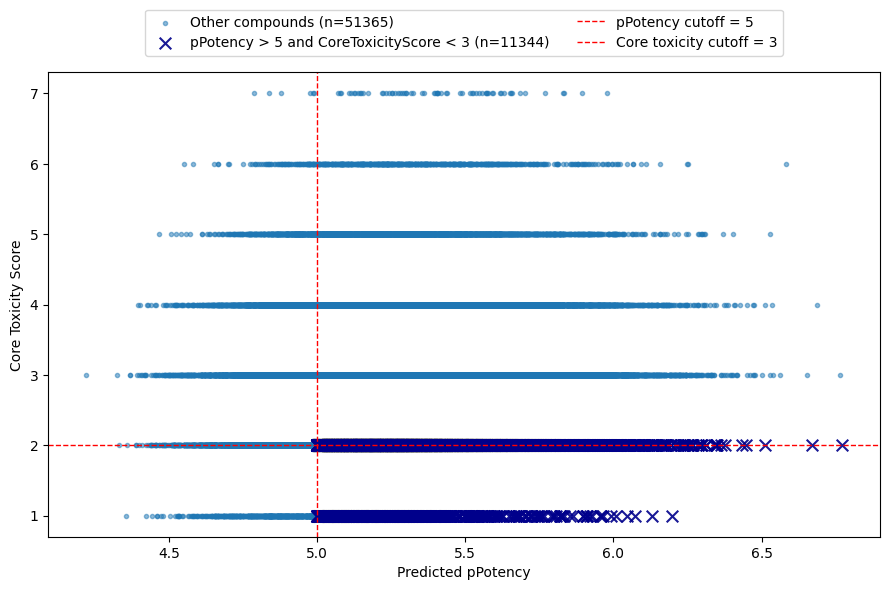

In [117]:
import matplotlib.pyplot as plt

plotcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity = (
    combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.copy()
)

# Define highlighted compounds
highlightMask = (
    (plotcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity["pPotency_prediction"] > 5) &
    (plotcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity["CoreToxicityScore"] < 3)
)

backgroundDF = plotcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity[~highlightMask]
highlightDF = plotcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity[highlightMask]

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)

plt.figure(figsize=(9, 6))

# Plot all other compounds
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["CoreToxicityScore"],
    alpha=0.5,
    marker=".",
    label=f"Other compounds (n={otherCount})"
)

# Plot high-potency, low-toxicity compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["CoreToxicityScore"],
    alpha=0.9,
    marker="x",
    s=70,
    c="darkblue",
    label=f"pPotency > 5 and CoreToxicityScore < 3 (n={highlightCount})"
)

plt.axvline(x=5, c='r', linestyle="--", linewidth=1, label="pPotency cutoff = 5")
plt.axhline(y=2, c='r', linestyle="--", linewidth=1, label="Core toxicity cutoff = 3")

plt.xlabel("Predicted pPotency")
plt.ylabel("Core Toxicity Score")
#plt.title("Predicted Potency vs Core Toxicity")
#plt.grid(True, alpha=0.3)

# Put legend outside the plot
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()

plt.show()

### Step 12 — List high-potency, low-core-toxicity molecules

This table keeps molecules with:

- `pPotency_prediction > 5`
- `CoreToxicityScore < 2`

These are attractive first-pass candidates because they combine stronger predicted potency with no direct core-toxicity alerts under this rule-based screen.


In [87]:
highPotencyLowToxicitycombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity = (
    combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[
        (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["pPotency_prediction"] > 5) &
        (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["CoreToxicityScore"] < 2)
    ]
    .sort_values(
        by=["pPotency_prediction", "MechanisticAlertScore", "AdmeLiabilityScore", "PriorityScore"],
        ascending=[False, True, True, False]
    )
    .reset_index(drop=True)
)

displayColsHighPotency = [
    "SMILES",
    "pPotency_prediction",
    "pPotency_std",
    "CoreToxicityScore",
    "MechanisticAlertScore",
    "AdmeLiabilityScore",
    "SafetyPriorityCategory",
    "PriorityScore"
]
displayColsHighPotency = [col for col in displayColsHighPotency if col in highPotencyLowToxicitycombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity.columns]

print("High-potency and low-core-toxicity candidate count:", len(highPotencyLowToxicitycombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity))
highPotencyLowToxicitycombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity[displayColsHighPotency]

High-potency and low-core-toxicity candidate count: 886


,SMILES,pPotency_prediction,pPotency_std,CoreToxicityScore,MechanisticAlertScore,AdmeLiabilityScore,SafetyPriorityCategory,PriorityScore
0,Cc1c(CNC2CCC(C)CC2)c(C(=O)O)c(C)n1Cc1ccc(F)cc1Cl,6.198254,0.609348,1,0,6,Moderate Risk,1.698254
1,Cc1ccc(-n2c(C)c(CNC3CCC(C)CC3)c(C(=O)O)c2C)cc1,6.130658,0.610047,1,0,5,Moderate Risk,2.130658
2,CCN1C(=O)NC(c2cccc(C)c2)C2=C1CN(C(C)(C)C(=O)NC...,6.073406,0.608729,1,0,5,Moderate Risk,2.073406
3,CCOC(=O)C1=C(CN2CCC(C(N)=O)CC2)NC(=O)NC1c1cccc...,6.045811,0.610128,1,0,5,Moderate Risk,2.045811
4,COc1ccc(Cn2c(C)c(CNCc3ccco3)c(C(=O)O)c2C)cc1,6.009217,0.609939,1,0,5,Moderate Risk,2.009217
...,...,...,...,...,...,...,...,...
881,O=C(Cc1ccccc1Cl)NCC(O)C1CCCCC1,5.000804,0.611072,1,0,6,Moderate Risk,0.500804
882,CC(=O)NC[C@H]1CCN(S(=O)(=O)c2ccc3c(c2)OCCO3)C[...,5.000687,0.616817,1,0,5,Moderate Risk,1.000687
883,CCc1nncn1CCNC(=O)N1CCCC(C)CC1,5.000521,0.611522,1,0,4,Moderate Risk,1.500521
884,COCCn1cc(NC(=O)CCC2CCCCO2)ccc1=O,5.000406,0.610390,1,0,5,Moderate Risk,1.000406


### Step 13 — 2D comparison plot: potency vs safety and liability scores

This second plot compares three score types against predicted potency in the same 2D figure:

- **CoreToxicityScore**
- **MechanisticAlertScore**
- **AdmeLiabilityScore**

All points use a dotted marker. This helps distinguish compounds that look clean in direct toxicity but still carry mechanistic or ADME burdens.


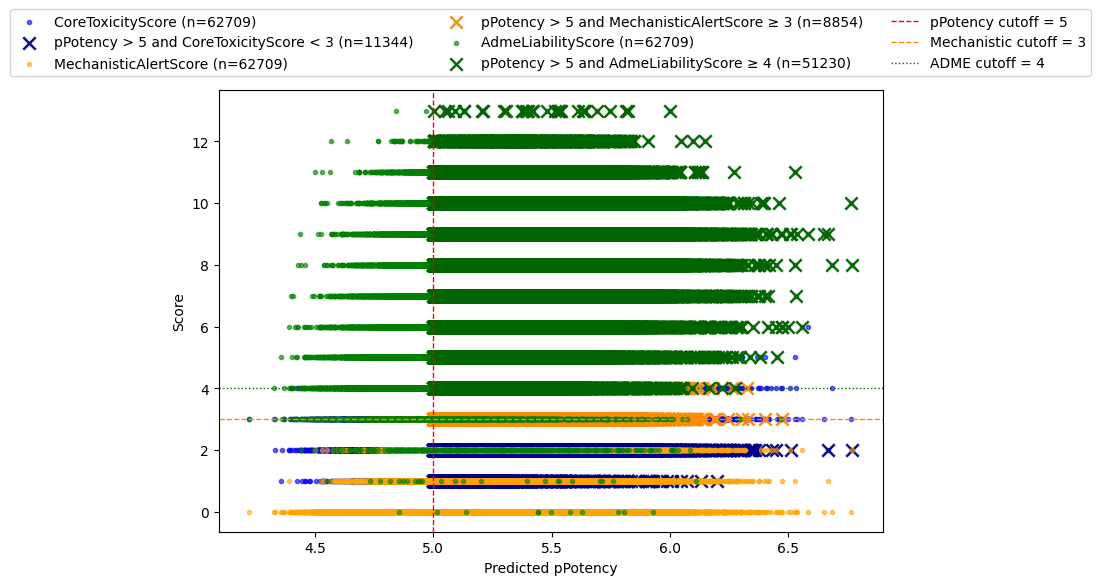

In [118]:
import matplotlib.pyplot as plt

comparisonDF = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.copy()

# Masks
coreMask = (
    (comparisonDF["pPotency_prediction"] > 5) &
    (comparisonDF["CoreToxicityScore"] < 3)
)
mechMask = (
    (comparisonDF["pPotency_prediction"] > 5) &
    (comparisonDF["MechanisticAlertScore"] >= 3)
)
admeMask = (
    (comparisonDF["pPotency_prediction"] > 5) &
    (comparisonDF["AdmeLiabilityScore"] >= 4)
)

coreCount = coreMask.sum()
mechCount = mechMask.sum()
admeCount = admeMask.sum()
totalCount = len(comparisonDF)

plt.figure(figsize=(10, 6))

# CoreToxicityScore full distribution: blue dots
plt.scatter(
    comparisonDF["pPotency_prediction"],
    comparisonDF["CoreToxicityScore"],
    alpha=0.6,
    marker=".",
    c="blue",
    label=f"CoreToxicityScore (n={totalCount})"
)

# Dark blue cross: pPotency > 5 and CoreToxicityScore < 3
plt.scatter(
    comparisonDF.loc[coreMask, "pPotency_prediction"],
    comparisonDF.loc[coreMask, "CoreToxicityScore"],
    alpha=0.95,
    marker="x",
    s=80,
    c="darkblue",
    linewidths=1.8,
    label=f"pPotency > 5 and CoreToxicityScore < 3 (n={coreCount})"
)

# MechanisticAlertScore full distribution: orange dots
plt.scatter(
    comparisonDF["pPotency_prediction"],
    comparisonDF["MechanisticAlertScore"],
    alpha=0.6,
    marker=".",
    c="orange",
    label=f"MechanisticAlertScore (n={totalCount})"
)

# Dark orange cross: pPotency > 5 and MechanisticAlertScore >= 3
plt.scatter(
    comparisonDF.loc[mechMask, "pPotency_prediction"],
    comparisonDF.loc[mechMask, "MechanisticAlertScore"],
    alpha=0.95,
    marker="x",
    s=80,
    c="darkorange",
    linewidths=1.8,
    label=f"pPotency > 5 and MechanisticAlertScore ≥ 3 (n={mechCount})"
)

# AdmeLiabilityScore full distribution: green dots
plt.scatter(
    comparisonDF["pPotency_prediction"],
    comparisonDF["AdmeLiabilityScore"],
    alpha=0.6,
    marker=".",
    c="green",
    label=f"AdmeLiabilityScore (n={totalCount})"
)

# Dark green cross: pPotency > 5 and AdmeLiabilityScore >= 4
plt.scatter(
    comparisonDF.loc[admeMask, "pPotency_prediction"],
    comparisonDF.loc[admeMask, "AdmeLiabilityScore"],
    alpha=0.95,
    marker="x",
    s=80,
    c="darkgreen",
    linewidths=1.8,
    label=f"pPotency > 5 and AdmeLiabilityScore ≥ 4 (n={admeCount})"
)

plt.axvline(x=5, c="r", linestyle="--", linewidth=1, label="pPotency cutoff = 5")
plt.axhline(y=3, c="darkorange", linestyle="--", linewidth=1, label="Mechanistic cutoff = 3")
plt.axhline(y=4, c="darkgreen", linestyle=":", linewidth=1, label="ADME cutoff = 4")

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
#plt.title("Predicted Potency vs Core Toxicity, Mechanistic Alerts, and ADME Liabilities")
#plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.tight_layout()
plt.show()

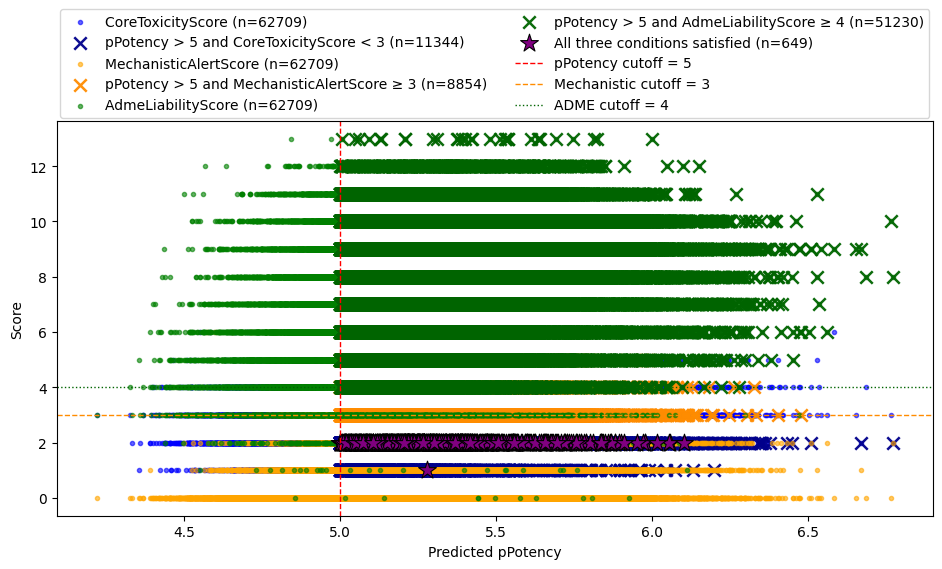

In [119]:
import matplotlib.pyplot as plt

comparisonDF = combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored.copy()

# Individual masks
coreMask = (
    (comparisonDF["pPotency_prediction"] > 5) &
    (comparisonDF["CoreToxicityScore"] < 3)
)
mechMask = (
    (comparisonDF["pPotency_prediction"] > 5) &
    (comparisonDF["MechanisticAlertScore"] >= 3)
)
admeMask = (
    (comparisonDF["pPotency_prediction"] > 5) &
    (comparisonDF["AdmeLiabilityScore"] >= 4)
)

# Combined mask: satisfies all three conditions at once
combinedMask = coreMask & mechMask & admeMask

coreCount = coreMask.sum()
mechCount = mechMask.sum()
admeCount = admeMask.sum()
combinedCount = combinedMask.sum()
totalCount = len(comparisonDF)

plt.figure(figsize=(10, 6))

# CoreToxicityScore full distribution: blue dots
plt.scatter(
    comparisonDF["pPotency_prediction"],
    comparisonDF["CoreToxicityScore"],
    alpha=0.6,
    marker=".",
    c="blue",
    label=f"CoreToxicityScore (n={totalCount})"
)

# Dark blue cross: pPotency > 5 and CoreToxicityScore < 3
plt.scatter(
    comparisonDF.loc[coreMask, "pPotency_prediction"],
    comparisonDF.loc[coreMask, "CoreToxicityScore"],
    alpha=0.95,
    marker="x",
    s=80,
    c="darkblue",
    linewidths=1.8,
    label=f"pPotency > 5 and CoreToxicityScore < 3 (n={coreCount})"
)

# MechanisticAlertScore full distribution: orange dots
plt.scatter(
    comparisonDF["pPotency_prediction"],
    comparisonDF["MechanisticAlertScore"],
    alpha=0.6,
    marker=".",
    c="orange",
    label=f"MechanisticAlertScore (n={totalCount})"
)

# Dark orange cross: pPotency > 5 and MechanisticAlertScore >= 3
plt.scatter(
    comparisonDF.loc[mechMask, "pPotency_prediction"],
    comparisonDF.loc[mechMask, "MechanisticAlertScore"],
    alpha=0.95,
    marker="x",
    s=80,
    c="darkorange",
    linewidths=1.8,
    label=f"pPotency > 5 and MechanisticAlertScore ≥ 3 (n={mechCount})"
)

# AdmeLiabilityScore full distribution: green dots
plt.scatter(
    comparisonDF["pPotency_prediction"],
    comparisonDF["AdmeLiabilityScore"],
    alpha=0.6,
    marker=".",
    c="green",
    label=f"AdmeLiabilityScore (n={totalCount})"
)

# Dark green cross: pPotency > 5 and AdmeLiabilityScore >= 4
plt.scatter(
    comparisonDF.loc[admeMask, "pPotency_prediction"],
    comparisonDF.loc[admeMask, "AdmeLiabilityScore"],
    alpha=0.95,
    marker="x",
    s=80,
    c="darkgreen",
    linewidths=1.8,
    label=f"pPotency > 5 and AdmeLiabilityScore ≥ 4 (n={admeCount})"
)

# Combined mask overlay: all three conditions satisfied
plt.scatter(
    comparisonDF.loc[combinedMask, "pPotency_prediction"],
    comparisonDF.loc[combinedMask, "CoreToxicityScore"],
    alpha=1.0,
    marker="*",
    s=180,
    c="purple",
    edgecolors="black",
    linewidths=0.8,
    label=f"All three conditions satisfied (n={combinedCount})"
)

#plt.ylim(1)
plt.axvline(x=5, c="r", linestyle="--", linewidth=1, label="pPotency cutoff = 5")
plt.axhline(y=3, c="darkorange", linestyle="--", linewidth=1, label="Mechanistic cutoff = 3")
plt.axhline(y=4, c="darkgreen", linestyle=":", linewidth=1, label="ADME cutoff = 4")

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
#plt.title("Predicted Potency vs Core Toxicity, Mechanistic Alerts, and ADME Liabilities")
#plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=2)
plt.tight_layout()
plt.show()

### Step 14 — List high-potency molecules with low direct toxicity and low additional liabilities

This stricter table keeps molecules with:

- `pPotency_prediction > 5`
- `CoreToxicityScore == 0`
- `MechanisticAlertScore <= 1`
- `AdmeLiabilityScore <= 2`

These candidates are often more attractive for follow-up because they look strong in potency, clean in direct safety, and relatively lighter in broader biological and ADME liabilities.


In [89]:
highPotencyBalancedcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity = (
    combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored[
        (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["pPotency_prediction"] > 5) &
        (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["CoreToxicityScore"] < 2) &
        (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["MechanisticAlertScore"] <= 1) &
        (combinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity_scored["AdmeLiabilityScore"] <= 2)
    ]
    .sort_values(
        by=["pPotency_prediction", "MechanisticAlertScore", "AdmeLiabilityScore", "PriorityScore"],
        ascending=[False, True, True, False]
    )
    .reset_index(drop=True)
)

displayColsBalanced = [
    "SMILES",
    "pPotency_prediction",
    "pPotency_std",
    "CoreToxicityScore",
    "MechanisticAlertScore",
    "AdmeLiabilityScore",
    "SafetyPenaltyScore",
    "SafetyPriorityCategory",
    "PriorityScore"
]
displayColsBalanced = [col for col in displayColsBalanced if col in highPotencyBalancedcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity.columns]

print("High-potency, low-core-toxicity, low-liability candidate count:", len(highPotencyBalancedcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity))
highPotencyBalancedcombinedEbolaVirus_wART_EnamineDataset_predicted_all_wToxicity[displayColsBalanced]

High-potency, low-core-toxicity, low-liability candidate count: 17


,SMILES,pPotency_prediction,pPotency_std,CoreToxicityScore,MechanisticAlertScore,AdmeLiabilityScore,SafetyPenaltyScore,SafetyPriorityCategory,PriorityScore
0,CN1CCN(c2ccc(CNC(=O)[C@H]3CN(Cc4ccccc4)C[C@H]3...,5.705955,0.612932,1,0,1,4.0,Moderate Risk,3.705955
1,O=C(NCc1cccc(CNC(=O)C(=O)NCC2CCCO2)c1)C(=O)NCC...,5.663222,0.609512,1,0,2,5.0,Moderate Risk,3.163222
2,CCOC(=O)c1c(C)n(C)c2ccc(O)c(CN3CCN(C)CC3)c12.O...,5.578010,0.609333,1,0,0,3.0,Moderate Risk,4.078010
3,Cc1cn(C)c(CC(=O)NCc2ccc(CN3CCCCCC3)o2)c1C(=O)O,5.527350,0.608551,1,0,2,5.0,Moderate Risk,3.027350
4,CC(C)S(=O)(=O)c1ccc(CC(=O)NCC(O)Cn2ccccc2=O)cc1,5.458067,0.615270,1,0,2,5.0,Moderate Risk,2.958067
5,CCNC(=O)Cn1c(CO)cnc1SCC(=O)Nc1ccc(C(N)=O)cc1,5.431297,0.610106,1,0,2,5.0,Moderate Risk,2.931297
6,CC(=O)Nc1ccc(S(=O)(=O)NC2=NCN(CCCN(C)C)CN2)cc1,5.397479,0.610368,1,0,1,4.0,Moderate Risk,3.397479
7,CC(N)C(O)c1cccc(O)c1,5.373135,0.608867,1,0,2,5.0,Moderate Risk,2.873135
8,CCn1cc(C)c(C(=O)O)c1CC(=O)N1CCC(N2CCCCC2)CC1,5.340718,0.608644,1,0,2,5.0,Moderate Risk,2.840718
9,COc1ccc(S(=O)(=O)NC2=NCN(CCCN(C)C)CN2)cc1OC,5.279766,0.610748,1,0,2,5.0,Moderate Risk,2.779766
